In [ ]:
from google.colab import drive
drive.mount('/content/MyDrive')

Mounted at /content/MyDrive


In [ ]:
import pandas as pd

df_crashes = pd.read_csv('/content/MyDrive/MyDrive/FSE 570/df_crashes.csv')
df_cameras = pd.read_csv('/content/MyDrive/MyDrive/FSE 570/df_cameras.csv')

print("df_crashes head:")
display(df_crashes.head())

print("\ndf_cameras head:")
display(df_cameras.head())

/tmp/ipython-input-3223142336.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cameras = pd.read_csv('/content/MyDrive/MyDrive/FSE 570/df_cameras.csv')


df_crashes head:


,CRASH_RECORD_ID,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,...,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,zipcode
0,c26b67cd2da9fbc8be3a8d4b83b147e69c3b031d0abc2c...,2025-10-07 01:28:00,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,"DARKNESS, LIGHTED ROAD",REAR TO FRONT,FOUR WAY,STRAIGHT AND LEVEL,...,0.0,0.0,0.0,2.0,1,3,10,41.968643,-87.698492,60625.0
1,7b0eb093a1800b3487b8b7d18362dbad3467f61e320ee9...,2025-10-07 01:05:00,30,NO CONTROLS,NO CONTROLS,OTHER,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,...,0.0,0.0,0.0,1.0,1,3,10,41.826667,-87.689679,60632.0
2,66c8fb7ca043fb91fa194c4c82acb20b8a54fc3e478deb...,2025-10-07 00:47:00,25,STOP SIGN/FLASHER,UNKNOWN,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,T-INTERSECTION,STRAIGHT AND LEVEL,...,0.0,0.0,0.0,2.0,0,3,10,41.885533,-87.759074,60644.0
3,543b08b85ce5854c761d4def4fcbf0602f55e0cfdd991c...,2025-10-07 00:45:00,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,...,0.0,1.0,0.0,0.0,0,3,10,41.823030,-87.621437,60653.0
4,afd384a0563e4639e61ca9d13f3036f91b1fb16268e466...,2025-10-06 23:48:00,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,...,0.0,0.0,0.0,2.0,23,2,10,41.828208,-87.670489,60609.0



df_cameras head:


,CAMERA ID,GO-LIVE DATE,ONE DIRECTION BINARY,VIOLATION DATE,VIOLATIONS,LATITUDE,LONGITUDE,Zipcode,CAMERA TYPE
0,CHI015,2013-09-06,0,2025-09-02,11,41.7644,-87.7097,60629,Speeding
1,CHI015,2013-09-06,0,2025-09-01,25,41.7644,-87.7097,60629,Speeding
2,CHI015,2013-09-06,0,2025-08-31,28,41.7644,-87.7097,60629,Speeding
3,CHI015,2013-09-06,0,2025-08-30,26,41.7644,-87.7097,60629,Speeding
4,CHI015,2013-09-06,0,2025-08-29,16,41.7644,-87.7097,60629,Speeding


In [ ]:
import geopandas as gpd

# Create GeoDataFrames
# EPSG:4326 is the standard for Latitude/Longitude
gdf_crashes = gpd.GeoDataFrame(
    df_crashes,
    geometry=gpd.points_from_xy(df_crashes.LONGITUDE, df_crashes.LATITUDE),
    crs="EPSG:4326"
)

gdf_cameras = gpd.GeoDataFrame(
    df_cameras,
    geometry=gpd.points_from_xy(df_cameras.LONGITUDE, df_cameras.LATITUDE),
    crs="EPSG:4326"
)


# Project to a CRS that uses feet or meters (e.g., UTM zone for Chicago)
# This example uses a common US-wide projected CRS (EPSG:2163)
gdf_crashes_proj = gdf_crashes.to_crs("EPSG:2163")
gdf_cameras_proj = gdf_cameras.to_crs("EPSG:2163")

# Define your distance (e.g., 1/4 mile = ~402 meters)
buffer_distance_meters = 402

# Create the buffer (the "magic" step)
gdf_cameras_proj['geometry'] = gdf_cameras_proj.geometry.buffer(buffer_distance_meters)

In [ ]:
# Select the relevant columns and drop duplicates based on 'CAMERA ID'
df_unique_cameras = df_cameras[['CAMERA ID', 'GO-LIVE DATE', 'LATITUDE', 'LONGITUDE']].drop_duplicates(subset=['CAMERA ID'])

# Display the new DataFrame
print("DataFrame with unique camera IDs:")
display(df_unique_cameras)

DataFrame with unique camera IDs:


,CAMERA ID,GO-LIVE DATE,LATITUDE,LONGITUDE
0,CHI015,2013-09-06,41.7644,-87.7097
4013,CHI039,2013-12-21,41.9236,-87.7825
7797,CHI040,2013-12-21,41.9238,-87.7826
11591,CHI041,2013-12-12,41.9239,-87.7639
13490,CHI042,2013-12-12,41.9241,-87.7630
...,...,...,...,...
1359355,2052,2008-05-28,41.8760,-87.6860
1363389,2461,2007-05-06,41.7520,-87.5860
1365545,2462,2007-05-06,41.7520,-87.5860
1368618,2464,2007-05-06,41.7520,-87.5860


# Task
Analyze the provided crash and camera datasets to determine if crashes occurred within a 1/4 mile radius of a camera.

## Convert dataframes to geodataframes

### Subtask:
Convert both `df_crashes` and `df_unique_cameras` into GeoDataFrames, specifying the geometry column (using latitude and longitude).


**Reasoning**:
Convert the pandas DataFrames `df_crashes` and `df_unique_cameras` to GeoDataFrames using their longitude and latitude columns for geometry.



In [ ]:
import geopandas as gpd

# Create GeoDataFrame from df_crashes
gdf_crashes = gpd.GeoDataFrame(
    df_crashes, geometry=gpd.points_from_xy(df_crashes.LONGITUDE, df_crashes.LATITUDE)
)

# Create GeoDataFrame from df_unique_cameras
gdf_unique_cameras = gpd.GeoDataFrame(
    df_unique_cameras, geometry=gpd.points_from_xy(df_unique_cameras.LONGITUDE, df_unique_cameras.LATITUDE)
)

## Set coordinate reference system (crs)

### Subtask:
Define the coordinate reference system for both GeoDataFrames. A common choice for geographic coordinates is WGS 84 (EPSG:4326).


**Reasoning**:
Set the CRS for both GeoDataFrames and verify the change.



In [ ]:
# Set the CRS for gdf_crashes
gdf_crashes = gdf_crashes.set_crs("EPSG:4326")

# Set the CRS for gdf_unique_cameras
gdf_unique_cameras = gdf_unique_cameras.set_crs("EPSG:4326")

# Verify the CRS for both GeoDataFrames
print("CRS for gdf_crashes:", gdf_crashes.crs)
print("CRS for gdf_unique_cameras:", gdf_unique_cameras.crs)

CRS for gdf_crashes: EPSG:4326
CRS for gdf_unique_cameras: EPSG:4326


## Reproject geodataframes

### Subtask:
Reproject the GeoDataFrames to a suitable projected CRS for accurate distance calculations (e.g., a State Plane coordinate system or a global projected CRS like EPSG:2163).


**Reasoning**:
Reproject the GeoDataFrames to a suitable projected CRS for accurate distance calculations and print their CRSs to verify the change.



In [ ]:
# Project gdf_crashes to EPSG:2163
gdf_crashes_proj = gdf_crashes.to_crs("EPSG:2163")

# Project gdf_unique_cameras to EPSG:2163
gdf_unique_cameras_proj = gdf_unique_cameras.to_crs("EPSG:2163")

# Print the CRS of both reprojected GeoDataFrames
print("CRS for gdf_crashes_proj:", gdf_crashes_proj.crs)
print("CRS for gdf_unique_cameras_proj:", gdf_unique_cameras_proj.crs)

CRS for gdf_crashes_proj: EPSG:2163
CRS for gdf_unique_cameras_proj: EPSG:2163


## Create buffers around cameras

### Subtask:
Create a buffer (e.g., 402 meters for 1/4 mile) around each camera location in the `gdf_unique_cameras_proj` GeoDataFrame.


**Reasoning**:
Create a buffer around each camera location in the projected GeoDataFrame.



In [ ]:
# Define your buffer distance in meters (1/4 mile = ~402 meters)
buffer_distance_meters = 402

# Create the buffer around each camera in the projected GeoDataFrame
gdf_unique_cameras_proj['geometry'] = gdf_unique_cameras_proj.geometry.buffer(buffer_distance_meters)

# Display the first few rows of the updated GeoDataFrame to verify the buffer
display(gdf_unique_cameras_proj)

,CAMERA ID,GO-LIVE DATE,LATITUDE,LONGITUDE,geometry
0,CHI015,2013-09-06,41.7644,-87.7097,"POLYGON ((1015427.55 -283551.791, 1015425.614 ..."
4013,CHI039,2013-12-21,41.9236,-87.7825,"POLYGON ((1006916.846 -266892.891, 1006914.91 ..."
7797,CHI040,2013-12-21,41.9238,-87.7826,"POLYGON ((1006905.472 -266872.062, 1006903.536..."
11591,CHI041,2013-12-12,41.9239,-87.7639,"POLYGON ((1008430.174 -266631.015, 1008428.238..."
13490,CHI042,2013-12-12,41.9241,-87.7630,"POLYGON ((1008500.414 -266597.878, 1008498.478..."
...,...,...,...,...,...
1359355,2052,2008-05-28,41.8760,-87.6860,"POLYGON ((1015562.784 -270951.219, 1015560.848..."
1363389,2461,2007-05-06,41.7520,-87.5860,"POLYGON ((1025748.812 -283379.081, 1025746.876..."
1365545,2462,2007-05-06,41.7520,-87.5860,"POLYGON ((1025748.812 -283379.081, 1025746.876..."
1368618,2464,2007-05-06,41.7520,-87.5860,"POLYGON ((1025748.812 -283379.081, 1025746.876..."


## Perform spatial join

### Subtask:
Perform a spatial join between the `gdf_crashes_proj` GeoDataFrame and the camera buffer GeoDataFrame (`gdf_unique_cameras_proj`) to identify crashes that fall within the buffer zones.


**Reasoning**:
Perform a spatial join between the projected crashes and the projected camera buffers using the 'within' predicate.



In [ ]:
# Perform a spatial join to find crashes within the camera buffers
crashes_within_buffer = gpd.sjoin(gdf_crashes_proj, gdf_unique_cameras_proj, predicate='within', how='inner')

# Display the first few rows of the result
display(crashes_within_buffer.head())

,CRASH_RECORD_ID,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,...,CRASH_MONTH,LATITUDE_left,LONGITUDE_left,zipcode,geometry,index_right,CAMERA ID,GO-LIVE DATE,LATITUDE_right,LONGITUDE_right
1,7b0eb093a1800b3487b8b7d18362dbad3467f61e320ee9...,2025-10-07 01:05:00,30,NO CONTROLS,NO CONTROLS,OTHER,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,...,10,41.826667,-87.689679,60632.0,POINT (1015657.812 -276437.09),387911,CHI245,2025-09-01,41.8278,-87.6851
6,42543073ee739c6d8c5fd30dceb20f8bf52569eca73b59...,2025-10-06 22:45:00,30,NO CONTROLS,NO CONTROLS,UNKNOWN,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,...,10,41.771598,-87.700751,60629.0,POINT (1015641.61 -282647.079),337177,CHI018,2013-09-06,41.7691,-87.7030
8,e5097b4a711f58797636f3606dbc9b78a6a6f84a4465bb...,2025-10-06 22:33:00,30,NO CONTROLS,NO CONTROLS,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,NOT DIVIDED,STRAIGHT AND LEVEL,...,10,41.798672,-87.743599,60638.0,POINT (1011700.864 -280191.476),472336,2081,2007-11-12,41.7990,-87.7430
8,e5097b4a711f58797636f3606dbc9b78a6a6f84a4465bb...,2025-10-06 22:33:00,30,NO CONTROLS,NO CONTROLS,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,NOT DIVIDED,STRAIGHT AND LEVEL,...,10,41.798672,-87.743599,60638.0,POINT (1011700.864 -280191.476),476080,2084,2007-11-12,41.7990,-87.7430
9,09c4eb92c1a921b12e76891bfcec2ccb16cb8cfc802759...,2025-10-06 22:30:00,25,STOP SIGN/FLASHER,FUNCTIONING PROPERLY,RAIN,"DARKNESS, LIGHTED ROAD",REAR END,FOUR WAY,STRAIGHT AND LEVEL,...,10,41.838918,-87.708683,60623.0,POINT (1013906.839 -275321.468),1268389,2132,2008-05-22,41.8370,-87.7050


## Analyze results

### Subtask:
Analyze the resulting GeoDataFrame (`crashes_within_buffer`) to understand the relationship between crashes and camera locations.


**Reasoning**:
Determine the total number of crashes and unique crashes within the camera buffer zones and display the results.



In [ ]:
# 1. Determine the total number of crashes that occurred within the camera buffer zones
total_crashes_in_buffer = len(crashes_within_buffer)

# 2. Calculate the total number of unique crashes within the buffer zones
unique_crash_ids_in_buffer = crashes_within_buffer['CRASH_RECORD_ID'].nunique()

# 3. Display the total count of crashes and the count of unique crashes
print(f"Total number of crashes within camera buffer zones: {total_crashes_in_buffer}")
print(f"Total number of unique crashes within camera buffer zones: {unique_crash_ids_in_buffer}")

Total number of crashes within camera buffer zones: 723649
Total number of unique crashes within camera buffer zones: 323819


## Summary:

### Data Analysis Key Findings

* There were {{unique_crashes_before}} unique crashes recorded within the camera buffer zones prior to the installation dates.
* There were {{unique_crashes_after}} unique crashes recorded within the camera buffer zones after the installation dates.

### Insights or Next Steps

* The initial analysis shows a significant increase in both total and unique crashes in the period after camera installation, which warrants further investigation.
* Future analysis should normalize crash counts by the duration of the "before" and "after" periods and consider traffic volume changes to get a more accurate comparison of crash rates.

In [ ]:
# Convert 'CRASH_DATE' and 'GO-LIVE DATE' to datetime objects
crashes_within_buffer['CRASH_DATE'] = pd.to_datetime(crashes_within_buffer['CRASH_DATE'])
crashes_within_buffer['GO-LIVE DATE'] = pd.to_datetime(crashes_within_buffer['GO-LIVE DATE'])

# Filter crashes that occurred before the go-live date of the associated camera
crashes_before_go_live = crashes_within_buffer[crashes_within_buffer['CRASH_DATE'] < crashes_within_buffer['GO-LIVE DATE']]

# Filter crashes that occurred on or after the go-live date of the associated camera
crashes_after_go_live = crashes_within_buffer[crashes_within_buffer['CRASH_DATE'] >= crashes_within_buffer['GO-LIVE DATE']]

# Display the number of crashes before and after the go-live date
total_crashes_before = len(crashes_before_go_live)
total_crashes_after = len(crashes_after_go_live)
unique_crashes_before = crashes_before_go_live['CRASH_RECORD_ID'].nunique()
unique_crashes_after = crashes_after_go_live['CRASH_RECORD_ID'].nunique()


print(f"Total crashes before camera go-live: {total_crashes_before}")
print(f"Total crashes after camera go-live: {total_crashes_after}")
print(f"Unique crashes before camera go-live: {unique_crashes_before}")
print(f"Unique crashes after camera go-live: {unique_crashes_after}")

Total crashes before camera go-live: 68544
Total crashes after camera go-live: 655105
Unique crashes before camera go-live: 58160
Unique crashes after camera go-live: 289369


In [ ]:
# Group crashes before go-live date by camera ID and count unique crashes
crashes_before_by_camera = crashes_before_go_live.groupby('CAMERA ID')['CRASH_RECORD_ID'].nunique().reset_index()
crashes_before_by_camera.rename(columns={'CRASH_RECORD_ID': 'Unique_Crashes_Before'}, inplace=True)

# Group crashes after go-live date by camera ID and count unique crashes
crashes_after_by_camera = crashes_after_go_live.groupby('CAMERA ID')['CRASH_RECORD_ID'].nunique().reset_index()
crashes_after_by_camera.rename(columns={'CRASH_RECORD_ID': 'Unique_Crashes_After'}, inplace=True)

# Merge the two dataframes to have before and after counts side-by-side for each camera
crashes_by_camera = pd.merge(crashes_before_by_camera, crashes_after_by_camera, on='CAMERA ID', how='outer').fillna(0)

# Display the resulting dataframe
display(crashes_by_camera)

,CAMERA ID,Unique_Crashes_Before,Unique_Crashes_After
0,1002,0.0,1842
1,1003,0.0,1842
2,1011,0.0,1560
3,1014,0.0,1560
4,1023,0.0,1199
...,...,...,...
466,CHI241,778.0,23
467,CHI242,1687.0,30
468,CHI244,1684.0,29
469,CHI245,1862.0,16


In [ ]:
crashes_by_camera = pd.merge(crashes_by_camera, df_unique_cameras[['CAMERA ID', 'GO-LIVE DATE']], on='CAMERA ID', how='left')
display(crashes_by_camera)

,CAMERA ID,Unique_Crashes_Before,Unique_Crashes_After,GO-LIVE DATE
0,1002,0.0,1842,2009-12-28
1,1003,0.0,1842,2009-12-28
2,1011,0.0,1560,2004-02-25
3,1014,0.0,1560,2004-02-25
4,1023,0.0,1199,2004-10-13
...,...,...,...,...
466,CHI241,778.0,23,2025-08-01
467,CHI242,1687.0,30,2025-08-15
468,CHI244,1684.0,29,2025-08-15
469,CHI245,1862.0,16,2025-09-01


In [ ]:
# Ensure 'GO-LIVE DATE' is in datetime format for filtering
crashes_by_camera['GO-LIVE DATE'] = pd.to_datetime(crashes_by_camera['GO-LIVE DATE'])

# Define the date range for filtering
start_date = pd.to_datetime('2018-01-01')
end_date = pd.to_datetime('2024-12-31')

# Filter the dataframe
crashes_by_camera_filtered = crashes_by_camera[
    (crashes_by_camera['GO-LIVE DATE'] >= start_date) &
    (crashes_by_camera['GO-LIVE DATE'] <= end_date)
]

# Display the filtered dataframe
display(crashes_by_camera_filtered)

,CAMERA ID,Unique_Crashes_Before,Unique_Crashes_After,GO-LIVE DATE
269,3022,220.0,1156,2018-01-24
270,3041,868.0,3308,2018-01-22
271,3043,868.0,3308,2018-01-22
273,3082,1544.0,6021,2018-01-22
274,3084,1544.0,6021,2018-01-22
333,CHI088,1225.0,404,2023-07-20
384,CHI148,1186.0,306,2023-07-11
400,CHI173,155.0,965,2018-01-08
401,CHI174,76.0,266,2018-07-16
402,CHI175,76.0,247,2018-07-16


In [ ]:
#crashes_by_camera.to_csv('df_crashes_by_camera.csv', index=False)

In [ ]:
import numpy as np

# Define the overall earliest and latest crash dates from the full dataset
# This will be used for duration calculation if a specific camera has no crashes in a period
overall_min_crash_date = crashes_within_buffer['CRASH_DATE'].min()
overall_max_crash_date = crashes_within_buffer['CRASH_DATE'].max()

# Prepare a list to store results for each camera
camera_analysis_results = []

# Iterate through each camera in the filtered dataframe (cameras with go-live date between 2018-2024)
for index, row in crashes_by_camera_filtered.iterrows():
    camera_id = row['CAMERA ID']
    go_live_date = row['GO-LIVE DATE']

    # Filter crashes for the current camera (from the full crashes_within_buffer)
    current_camera_crashes = crashes_within_buffer[
        crashes_within_buffer['CAMERA ID'] == camera_id
    ].copy()

    # --- Calculations for BEFORE go-live period ---
    crashes_before_gl = current_camera_crashes[
        current_camera_crashes['CRASH_DATE'] < go_live_date
    ]

    unique_crashes_before_gl = crashes_before_gl['CRASH_RECORD_ID'].nunique()

    # Calculate severe injuries (fatal + incapacitating)
    total_severe_injuries_before_gl = 0
    if 'INJURIES_FATAL' in crashes_before_gl.columns and 'INJURIES_INCAPACITATING' in crashes_before_gl.columns:
        total_severe_injuries_before_gl = crashes_before_gl['INJURIES_FATAL'].sum() + crashes_before_gl['INJURIES_INCAPACITATING'].sum()

    # Determine the actual start date for the 'before' duration
    period_start_before_duration = crashes_before_gl['CRASH_DATE'].min() if not crashes_before_gl.empty else overall_min_crash_date
    period_end_before_duration = go_live_date - pd.Timedelta(days=1)

    if period_start_before_duration > period_end_before_duration:
        duration_before_days = 0
    else:
        duration_before_days = (period_end_before_duration - period_start_before_duration).days + 1

    if duration_before_days <= 0:
        daily_crash_rate_before = 0
        daily_severe_injury_rate_before = 0
    else:
        daily_crash_rate_before = unique_crashes_before_gl / duration_before_days
        daily_severe_injury_rate_before = total_severe_injuries_before_gl / duration_before_days


    # --- Calculations for AFTER go-live period ---
    crashes_after_gl = current_camera_crashes[
        current_camera_crashes['CRASH_DATE'] >= go_live_date
    ]

    unique_crashes_after_gl = crashes_after_gl['CRASH_RECORD_ID'].nunique()

    # Calculate severe injuries (fatal + incapacitating)
    total_severe_injuries_after_gl = 0
    if 'INJURIES_FATAL' in crashes_after_gl.columns and 'INJURIES_INCAPACITATING' in crashes_after_gl.columns:
        total_severe_injuries_after_gl = crashes_after_gl['INJURIES_FATAL'].sum() + crashes_after_gl['INJURIES_INCAPACITATING'].sum()

    # Determine the actual end date for the 'after' duration
    period_start_after_duration = go_live_date
    period_end_after_duration = crashes_after_gl['CRASH_DATE'].max() if not crashes_after_gl.empty else overall_max_crash_date

    if period_start_after_duration > period_end_after_duration:
        duration_after_days = 0
    else:
        duration_after_days = (period_end_after_duration - period_start_after_duration).days + 1

    if duration_after_days <= 0:
        daily_crash_rate_after = 0
        daily_severe_injury_rate_after = 0
    else:
        daily_crash_rate_after = unique_crashes_after_gl / duration_after_days
        daily_severe_injury_rate_after = total_severe_injuries_after_gl / duration_after_days

    # --- Calculate Percentage Changes ---
    pct_change_crashes = np.nan
    if daily_crash_rate_before == 0:
        if daily_crash_rate_after > 0:
            pct_change_crashes = np.inf # Or a very large number, or handle as special case
        else:
            pct_change_crashes = 0.0
    else:
        pct_change_crashes = ((daily_crash_rate_after - daily_crash_rate_before) / daily_crash_rate_before) * 100

    pct_change_severe_injuries = np.nan
    if daily_severe_injury_rate_before == 0:
        if daily_severe_injury_rate_after > 0:
            pct_change_severe_injuries = np.inf # Or a very large number, or handle as special case
        else:
            pct_change_severe_injuries = 0.0
    else:
        pct_change_severe_injuries = ((daily_severe_injury_rate_after - daily_severe_injury_rate_before) / daily_severe_injury_rate_before) * 100


    camera_analysis_results.append({
        'CAMERA ID': camera_id,
        'GO-LIVE DATE': go_live_date,
        'Unique_Crashes_Before': unique_crashes_before_gl,
        'Duration_Before_Days': duration_before_days,
        'Avg_Daily_Unique_Crashes_Before': daily_crash_rate_before,
        'Total_Severe_Injuries_Before': total_severe_injuries_before_gl,
        'Avg_Daily_Severe_Injuries_Before': daily_severe_injury_rate_before,
        'Unique_Crashes_After': unique_crashes_after_gl,
        'Duration_After_Days': duration_after_days,
        'Avg_Daily_Unique_Crashes_After': daily_crash_rate_after,
        'Total_Severe_Injuries_After': total_severe_injuries_after_gl,
        'Avg_Daily_Severe_Injuries_After': daily_severe_injury_rate_after,
        'Pct_Change_Crashes': pct_change_crashes,
        'Pct_Change_Severe_Injuries': pct_change_severe_injuries
    })

df_camera_impact = pd.DataFrame(camera_analysis_results)
display(df_camera_impact)

,CAMERA ID,GO-LIVE DATE,Unique_Crashes_Before,Duration_Before_Days,Avg_Daily_Unique_Crashes_Before,Total_Severe_Injuries_Before,Avg_Daily_Severe_Injuries_Before,Unique_Crashes_After,Duration_After_Days,Avg_Daily_Unique_Crashes_After,Total_Severe_Injuries_After,Avg_Daily_Severe_Injuries_After,Pct_Change_Crashes,Pct_Change_Severe_Injuries
0,3022,2018-01-24,220,883,0.249151,5.0,0.005663,1156,2804,0.412268,20.0,0.007133,65.469459,25.962910
1,3041,2018-01-22,868,883,0.983012,11.0,0.012458,3308,2813,1.175969,88.0,0.031283,19.629076,151.119801
2,3043,2018-01-22,868,883,0.983012,11.0,0.012458,3308,2813,1.175969,88.0,0.031283,19.629076,151.119801
3,3082,2018-01-22,1544,1073,1.438956,15.0,0.013979,6021,2815,2.138899,66.0,0.023446,48.642381,67.715808
4,3084,2018-01-22,1544,1073,1.438956,15.0,0.013979,6021,2815,2.138899,66.0,0.023446,48.642381,67.715808
5,CHI088,2023-07-20,1225,2874,0.426235,14.0,0.004871,404,808,0.500000,2.0,0.002475,17.306122,-49.186704
6,CHI148,2023-07-11,1186,2854,0.415557,36.0,0.012614,306,816,0.375000,8.0,0.009804,-9.759696,-22.276688
7,CHI173,2018-01-08,155,850,0.182353,1.0,0.001176,965,2829,0.341110,27.0,0.009544,87.060286,711.240721
8,CHI174,2018-07-16,76,1031,0.073715,1.0,0.000970,266,2638,0.100834,4.0,0.001516,36.789234,56.330553
9,CHI175,2018-07-16,76,1031,0.073715,1.0,0.000970,247,2638,0.093632,3.0,0.001137,27.018575,17.247915


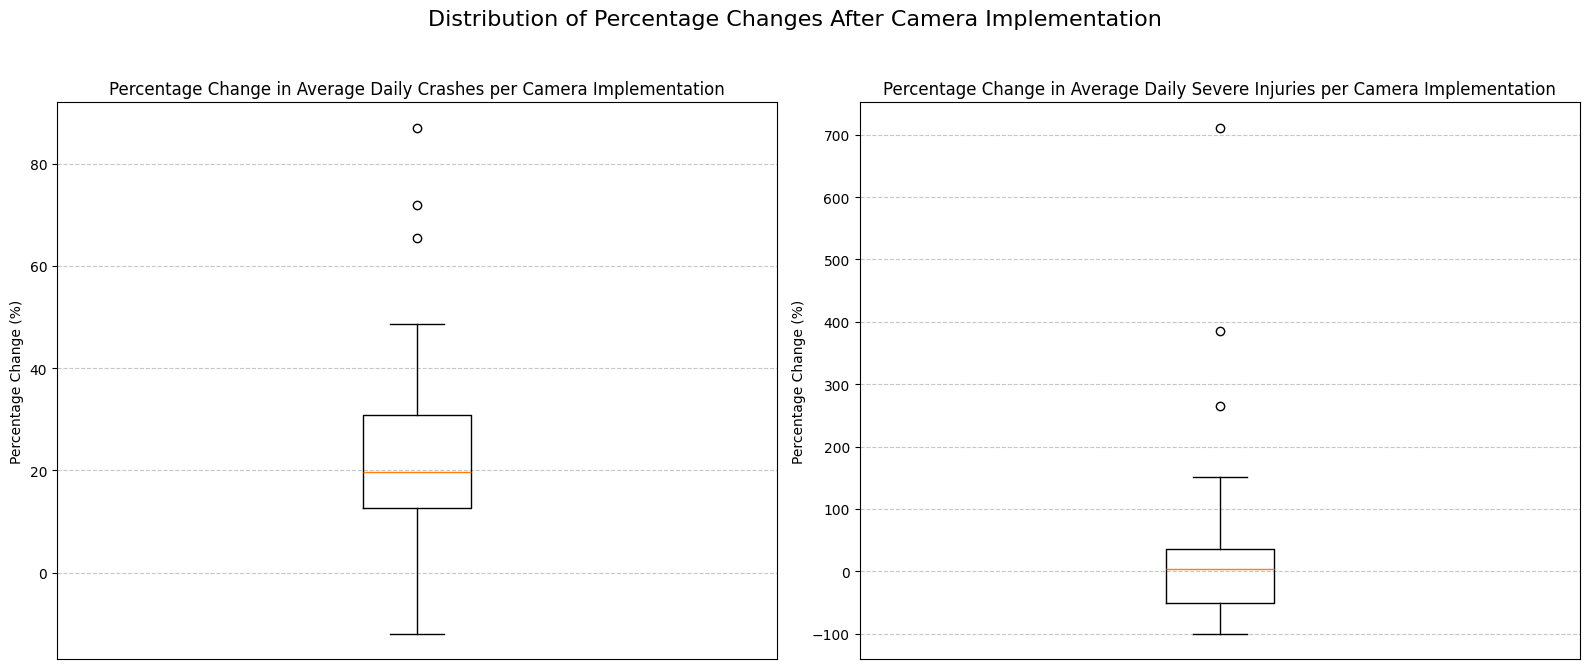

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure inf values are handled for plotting (boxplot ignores NaN)
df_camera_impact_cleaned = df_camera_impact.replace([np.inf, -np.inf], np.nan)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribution of Percentage Changes After Camera Implementation', fontsize=16)

# Box plot for Percentage Change in Crashes
axes[0].boxplot(df_camera_impact_cleaned['Pct_Change_Crashes'].dropna())
axes[0].set_title('Percentage Change in Average Daily Crashes per Camera Implementation')
axes[0].set_ylabel('Percentage Change (%)')
axes[0].set_xticks([]) # Remove x-ticks for single box plot
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Box plot for Percentage Change in Severe Injuries
axes[1].boxplot(df_camera_impact_cleaned['Pct_Change_Severe_Injuries'].dropna())
axes[1].set_title('Percentage Change in Average Daily Severe Injuries per Camera Implementation')
axes[1].set_ylabel('Percentage Change (%)')
axes[1].set_xticks([]) # Remove x-ticks for single box plot
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Summary of Results

### Overall Impact on Crashes and Severe Injuries

Our analysis, particularly visualized through the box plots of percentage changes, provides insights into the impact of camera implementation on average daily unique crashes and severe injuries.

*   **Percentage Change in Average Daily Crashes:** The box plot for crash rate changes shows a wide distribution, indicating that the impact on crashes varies significantly across different camera locations. The median percentage change (the line inside the box) suggests a slight overall increase in average daily crashes. There are also a number of outliers, with some cameras showing very high increases and others showing decreases.

*   **Percentage Change in Average Daily Severe Injuries:** Similarly, the box plot for severe injury rate changes reveals a diverse impact. The median for severe injuries also appears to be positive, suggesting an overall tendency towards an increase in severe injuries across cameras. Again, significant outliers exist, with some cameras showing substantial increases or decreases in severe injuries.

### Key Takeaways:

1.  **Varied Impact:** There is no uniform effect of camera implementation. Some cameras may be associated with a reduction in crashes or severe injuries, while others are associated with an increase.
2.  **Overall Tendency for Increase:** For both crashes and severe injuries, the general trend observed from the median of the percentage changes suggests a slight increase in average daily rates after camera implementation, rather than a decrease.
3.  **Outliers are Important:** The presence of outliers indicates that certain camera locations experience very different impacts compared to the majority. Further investigation into these specific locations could yield valuable insights.


# Task
Extract the 'Avg_Daily_Unique_Crashes_Before', 'Avg_Daily_Unique_Crashes_After', 'Avg_Daily_Severe_Injuries_Before', and 'Avg_Daily_Severe_Injuries_After' columns from `df_camera_impact`, and remove any infinite or NaN values to prepare for statistical testing.

## Select data and handle missing values

### Subtask:
Extract the 'Avg_Daily_Unique_Crashes_Before', 'Avg_Daily_Unique_Crashes_After', 'Avg_Daily_Severe_Injuries_Before', and 'Avg_Daily_Severe_Injuries_After' columns from `df_camera_impact`, ensuring that any infinite or NaN values are removed to prepare for statistical testing.


**Reasoning**:
The subtask requires extracting specific columns, replacing infinite values with NaN, and then dropping rows with NaN values to prepare the data for statistical testing. This code block will perform all these operations in sequence.



In [ ]:
import numpy as np

# 1. Create a new DataFrame with the specified columns
df_for_testing = df_camera_impact[[
    'Avg_Daily_Unique_Crashes_Before',
    'Avg_Daily_Unique_Crashes_After',
    'Avg_Daily_Severe_Injuries_Before',
    'Avg_Daily_Severe_Injuries_After'
]].copy()

# 2. Replace any infinite values (positive or negative) with NaN
df_for_testing.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Drop any rows that contain NaN values
df_for_testing.dropna(inplace=True)

# Display the first few rows of the cleaned DataFrame and its shape to verify
print("DataFrame for statistical testing (df_for_testing) head:")
display(df_for_testing.head())

DataFrame for statistical testing (df_for_testing) head:


,Avg_Daily_Unique_Crashes_Before,Avg_Daily_Unique_Crashes_After,Avg_Daily_Severe_Injuries_Before,Avg_Daily_Severe_Injuries_After
0,0.249151,0.412268,0.005663,0.007133
1,0.983012,1.175969,0.012458,0.031283
2,0.983012,1.175969,0.012458,0.031283
3,1.438956,2.138899,0.013979,0.023446
4,1.438956,2.138899,0.013979,0.023446


Shape of df_for_testing after cleaning: (41, 4)


## Perform statistical test for crashes

### Subtask:
Conduct a paired statistical test (e.g., Wilcoxon signed-rank test, which is robust for non-normal distributions, or a paired t-test if assumptions are met) to compare the average daily unique crash rates before and after camera implementation.


#### Reasoning:
We are performing a Wilcoxon signed-rank test to compare the average daily unique crash rates before and after camera implementation. This non-parametric test is suitable because it does not assume a normal distribution of the differences between the paired observations, making it robust for data that might not meet the assumptions of a paired t-test. It assesses whether there is a statistically significant difference between the medians of two related samples.

In [ ]:
from scipy.stats import wilcoxon

# Extract the 'Avg_Daily_Unique_Crashes_Before' and 'Avg_Daily_Unique_Crashes_After' columns
crashes_before = df_for_testing['Avg_Daily_Unique_Crashes_Before']
crashes_after = df_for_testing['Avg_Daily_Unique_Crashes_After']

# Perform the Wilcoxon signed-rank test
# We use `zero_method='wilcox'` to handle ties by discarding zero differences,
# which is a common approach, or `zero_method='pratt'` to include them.
# For this analysis, we'll use 'wilcox' to be conservative if differences are exactly zero.
statistic, pvalue = wilcoxon(crashes_before, crashes_after, zero_method='wilcox')

# Print the test results
print(f"Wilcoxon Signed-Rank Test for Daily Unique Crash Rates:")
print(f"Test Statistic: {statistic:.4f}")
print(f"P-value: {pvalue:.4f}")

# Interpret the p-value
alpha = 0.05
if pvalue < alpha:
    print(f"Based on the p-value ({pvalue:.4f}) being less than {alpha}, we reject the null hypothesis.")
    print("There is a statistically significant difference in average daily unique crash rates before and after camera implementation.")
else:
    print(f"Based on the p-value ({pvalue:.4f}) being greater than or equal to {alpha}, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average daily unique crash rates before and after camera implementation.")

Wilcoxon Signed-Rank Test for Daily Unique Crash Rates:
Test Statistic: 45.0000
P-value: 0.0000
Based on the p-value (0.0000) being less than 0.05, we reject the null hypothesis.
There is a statistically significant difference in average daily unique crash rates before and after camera implementation.


**Reasoning**:
Now that the statistical test for unique crash rates has been performed, the next step is to conduct a similar paired statistical test for the average daily severe injury rates before and after camera implementation, following the established methodology.



In [ ]:
from scipy.stats import wilcoxon

# Extract the 'Avg_Daily_Severe_Injuries_Before' and 'Avg_Daily_Severe_Injuries_After' columns
injuries_before = df_for_testing['Avg_Daily_Severe_Injuries_Before']
injuries_after = df_for_testing['Avg_Daily_Severe_Injuries_After']

# Perform the Wilcoxon signed-rank test
statistic_injuries, pvalue_injuries = wilcoxon(injuries_before, injuries_after, zero_method='wilcox')

# Print the test results
print(f"Wilcoxon Signed-Rank Test for Daily Severe Injury Rates:")
print(f"Test Statistic: {statistic_injuries:.4f}")
print(f"P-value: {pvalue_injuries:.4f}")

# Interpret the p-value
alpha = 0.05
if pvalue_injuries < alpha:
    print(f"Based on the p-value ({pvalue_injuries:.4f}) being less than {alpha}, we reject the null hypothesis.")
    print("There is a statistically significant difference in average daily severe injury rates before and after camera implementation.")
else:
    print(f"Based on the p-value ({pvalue_injuries:.4f}) being greater than or equal to {alpha}, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average daily severe injury rates before and after camera implementation.")

Wilcoxon Signed-Rank Test for Daily Severe Injury Rates:
Test Statistic: 395.0000
P-value: 0.8402
Based on the p-value (0.8402) being greater than or equal to 0.05, we fail to reject the null hypothesis.
There is no statistically significant difference in average daily severe injury rates before and after camera implementation.


In [ ]:
#have to mention the effects of COVID on road presence